# AirBnB
https://insideairbnb.com/get-the-data/

In [47]:
import pandas as pd

In [ ]:
df = pd.read_csv('../listings.csv')

In [49]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,821198084644106078,https://www.airbnb.com/rooms/821198084644106078,20250926170004,2025-09-27,city scrape,Bright and Peaceful Leblon Loft,Welcome! Come relax in our bright and stylish ...,Beautiful tree lined street just 3 blocks from...,https://a0.muscache.com/pictures/hosting/Hosti...,84350716,...,4.94,4.99,4.85,NaN,f,1,1,0,0,2.72
1,821198370698658112,https://www.airbnb.com/rooms/821198370698658112,20250926170004,2025-09-27,city scrape,Copacabana 100% reformado.,Guarantee of a safe and quality stay! <br /><...,"Copacabana, in the part near the neighborhood ...",https://a0.muscache.com/pictures/miso/Hosting-...,4347269,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
2,821200521820144734,https://www.airbnb.com/rooms/821200521820144734,20250926170004,2025-09-26,city scrape,hambiente familia,Relax with the whole family in this quiet acco...,NaN,https://a0.muscache.com/pictures/7485ea61-a28a...,499903412,...,NaN,NaN,NaN,NaN,t,2,1,1,0,NaN


In [50]:
df.room_type

0        Entire home/apt
1        Entire home/apt
2        Entire home/apt
3           Private room
4        Entire home/apt
              ...       
43063    Entire home/apt
43064       Private room
43065    Entire home/apt
43066       Private room
43067       Private room
Name: room_type, Length: 43068, dtype: str

In [51]:
col_interes = ['id', 'name', 'host_name', 'host_location', 'host_response_time', 'host_is_superhost', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_l30d', 'review_scores_rating', 'instant_bookable']

room_trad = {'Entire home/apt': 'Todo o espaço',
             'Private room': 'Quarto privativo',
             'Shared room' : 'Quarto compartilhado'}

In [52]:
df_treatment = df[col_interes].copy()

In [53]:
df_treatment.head(3)

,id,name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,neighbourhood_cleansed,latitude,longitude,...,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,number_of_reviews_l30d,review_scores_rating,instant_bookable
0,821198084644106078,Bright and Peaceful Leblon Loft,Katrina,"Minnesota, United States",within an hour,f,"Rio de Janeiro, Brazil",Leblon,-22.982818,-43.222457,...,4,1.5,2.0,3.0,$580.00,2,86,2,4.93,f
1,821198370698658112,Copacabana 100% reformado.,Patrick,"Rio de Janeiro, Brazil",within an hour,f,"Rio de Janeiro, Brazil",Copacabana,-22.984090,-43.191770,...,2,2.0,1.0,1.0,"$1,900.00",5,0,0,NaN,f
2,821200521820144734,hambiente familia,Vanessa,NaN,NaN,f,NaN,Pavuna,-22.814911,-43.379011,...,4,1.0,1.0,1.0,$700.00,1,0,0,NaN,t


In [54]:
df_treatment['room_type'] = df_treatment['room_type'].map(room_trad)

In [55]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      43068 non-null  int64  
 1   name                    43068 non-null  str    
 2   host_name               43057 non-null  str    
 3   host_location           34195 non-null  str    
 4   host_response_time      35890 non-null  str    
 5   host_is_superhost       41613 non-null  str    
 6   neighbourhood           16330 non-null  str    
 7   neighbourhood_cleansed  43068 non-null  str    
 8   latitude                43068 non-null  float64
 9   longitude               43068 non-null  float64
 10  property_type           43068 non-null  str    
 11  room_type               43046 non-null  str    
 12  accommodates            43068 non-null  int64  
 13  bathrooms               38635 non-null  float64
 14  bedrooms                42096 non-null  float64
 

In [56]:
df.host_response_time.value_counts()

host_response_time
within an hour        22227
within a few hours     6131
within a day           4258
a few days or more     3274
Name: count, dtype: int64

In [57]:
df_treatment['price_cleaned'] = df_treatment['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [58]:
remap_boolean = {'t' :  True, 'f': False}
df_treatment['host_is_superhost'] = df_treatment['host_is_superhost'].replace(remap_boolean).astype(bool)
df_treatment['instant_bookable'] = df_treatment['instant_bookable'].replace(remap_boolean).astype(bool)

In [59]:
def get_marker_color(room_type):
    cores = {
        'Entire home/apt': 'red',
        'Private room': 'blue',
        'Shared room': 'green'
    }
    return cores.get(room_type, 'gray')

In [60]:
df_treatment.price_cleaned.describe()

count     38670.000000
mean        717.535325
std        4388.082802
min          30.000000
25%         202.000000
50%         317.000000
75%         565.000000
max      500000.000000
Name: price_cleaned, dtype: float64

In [61]:
pd.set_option('display.max_rows', 10)

In [62]:
Bairros_perigosos = ['Centro', 'Bonsucesso', 'São Cristóvão', 'Caju', 'Pavuna', 'Complexo do Alemão', 'Complexo da Maré', 'Irajá', 'Piedade', 'Cascadura', 'Costas Barros', 'Senador Camará', 'Parada de Lucas', 'Brás de Pina', 'Vigário Geral', 'Barros Filhos', 'Complexo do Alemão', 'Triagem', 'Vila Kosmos']

In [63]:
df_treatment['bairro_perigoso'] = df_treatment['neighbourhood_cleansed'].isin(Bairros_perigosos).astype(int)

# 3. Verifique o resultado
print(df_treatment[['neighbourhood_cleansed', 'bairro_perigoso']].head(100))

      neighbourhood_cleansed  bairro_perigoso
0                     Leblon                0
1                 Copacabana                0
2                     Pavuna                1
3                     Leblon                0
4            Barra da Tijuca                0
..                       ...              ...
95               Jacarepaguá                0
96           Jardim Botânico                0
97  Recreio dos Bandeirantes                0
98                  Flamengo                0
99                  Botafogo                0

[100 rows x 2 columns]


In [64]:
df_treatment.to_csv("AirBnBLimpo.csv")

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns 

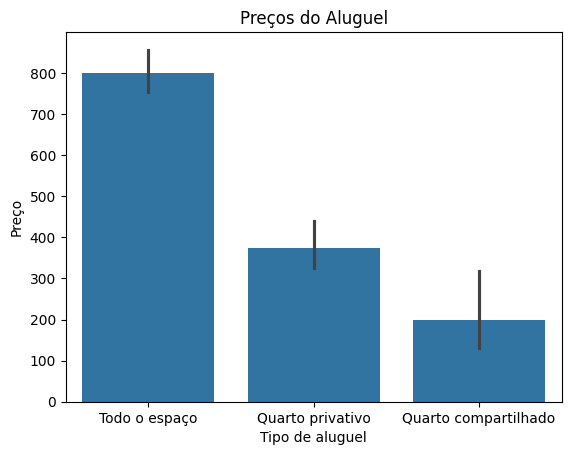

In [66]:
sns.barplot(df_treatment,
            x='room_type',
            y='price_cleaned')


plt.title('Preços do Aluguel')
plt.xlabel('Tipo de aluguel')
plt.ylabel('Preço')
plt.show()

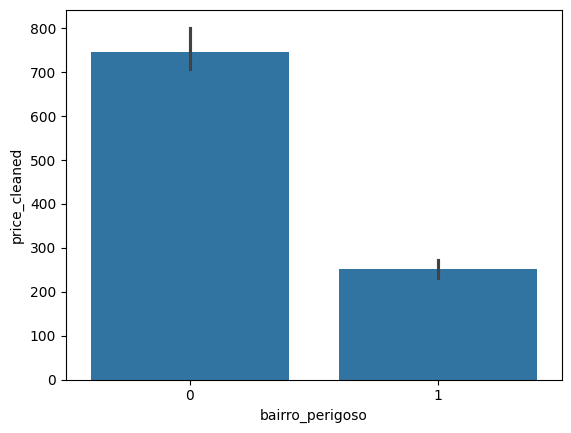

In [67]:
sns.barplot(df_treatment,
            x='bairro_perigoso',
            y='price_cleaned')

plt.show()

- total host
- avg price
- avg number review
- total listing
- gráfico de total de alugueis por bairro e tipo de aluguel
- grafico de numero de reviews
- mapa dos locais
- seleção de rating


- treinar para obter rating?
- treinar para prever preço?

In [68]:
df_treatment.minimum_nights.describe()

count    43068.000000
mean         3.652155
std         15.394401
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       1000.000000
Name: minimum_nights, dtype: float64

In [69]:
# df_treatment.bedrooms = df_treatment.bedrooms.fillna(df_treatment.bedrooms.median())
# df_treatment.beds = df_treatment.beds.fillna(df_treatment.beds.median())
# df_treatment.bathrooms = df_treatment.bathrooms.fillna(df_treatment.bathrooms.median())
# df_treatment.review_scores_rating = df_treatment.review_scores_rating.fillna(0)
df_treatment.host_response_time = df_treatment.host_response_time.fillna("Não informado")

In [70]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      43068 non-null  int64  
 1   name                    43068 non-null  str    
 2   host_name               43057 non-null  str    
 3   host_location           34195 non-null  str    
 4   host_response_time      43068 non-null  str    
 5   host_is_superhost       43068 non-null  bool   
 6   neighbourhood           16330 non-null  str    
 7   neighbourhood_cleansed  43068 non-null  str    
 8   latitude                43068 non-null  float64
 9   longitude               43068 non-null  float64
 10  property_type           43068 non-null  str    
 11  room_type               43046 non-null  str    
 12  accommodates            43068 non-null  int64  
 13  bathrooms               38635 non-null  float64
 14  bedrooms                42096 non-null  float64
 

In [71]:
df_treatment['bairro_perigoso'].value_counts()

bairro_perigoso
0    40544
1     2524
Name: count, dtype: int64

In [72]:
# Cria um dicionário onde cada chave é o valor do grupo (0 ou 1) 
# e o valor é o DataFrame correspondente filtrado
dfs_por_bairro = {nome_grupo: dados.drop(columns=['bairro_perigoso']) 
                 for nome_grupo, dados in df_treatment.groupby('bairro_perigoso')}

# Para acessar o DataFrame dos bairros perigosos:
# dfs_por_grupo[1]

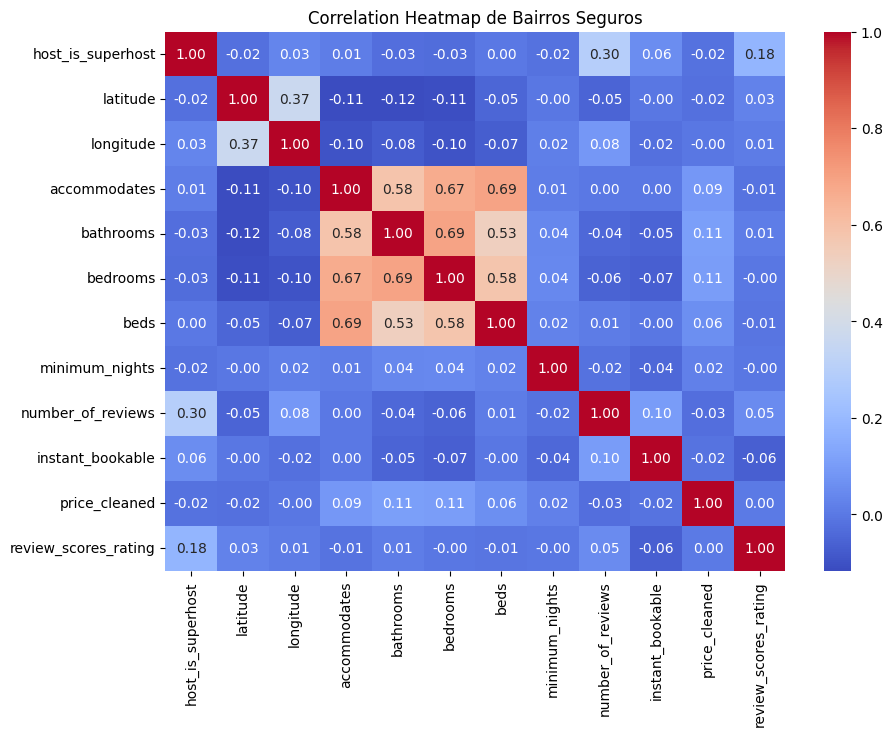

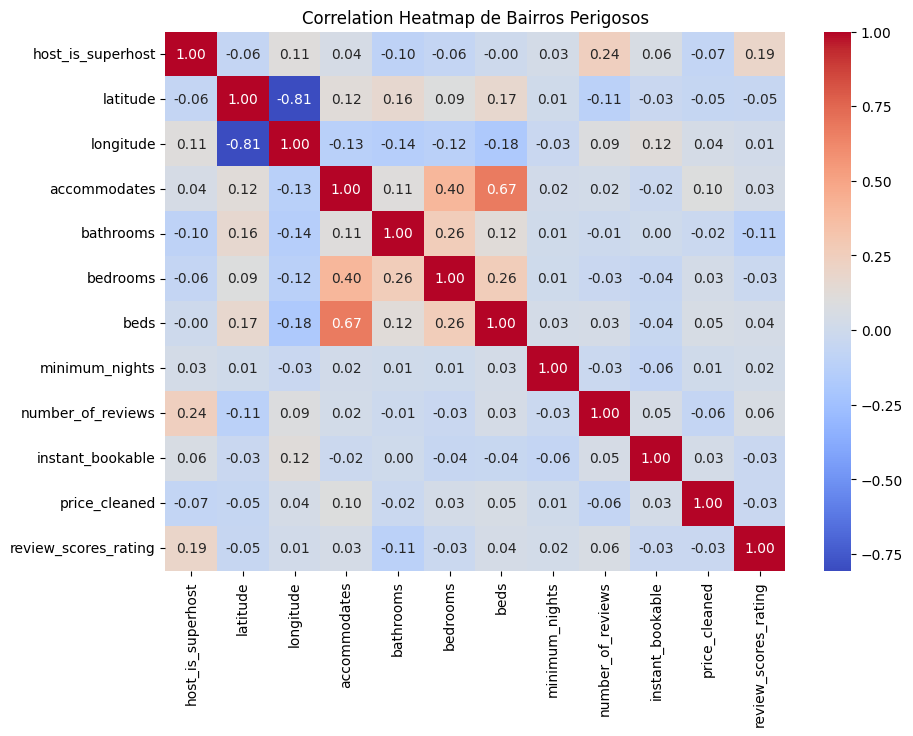

In [106]:
import seaborn as sns
plt.figure(figsize=(10, 7))
corr = dfs_por_bairro[0][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'review_scores_rating'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Seguros')
plt.show()

corr = dfs_por_bairro[1][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'review_scores_rating'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Perigosos')
plt.show()

In [85]:

dfs_por_quartos = {nome_grupo: dados.drop(columns=['room_type']) 
                 for nome_grupo, dados in df_treatment.groupby('room_type')}

In [108]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [109]:
# df_treatment é o seu DataFrame
df_treatment.loc[df_treatment['beds'] == 1, 'room_type'] = 'Quarto privativo'

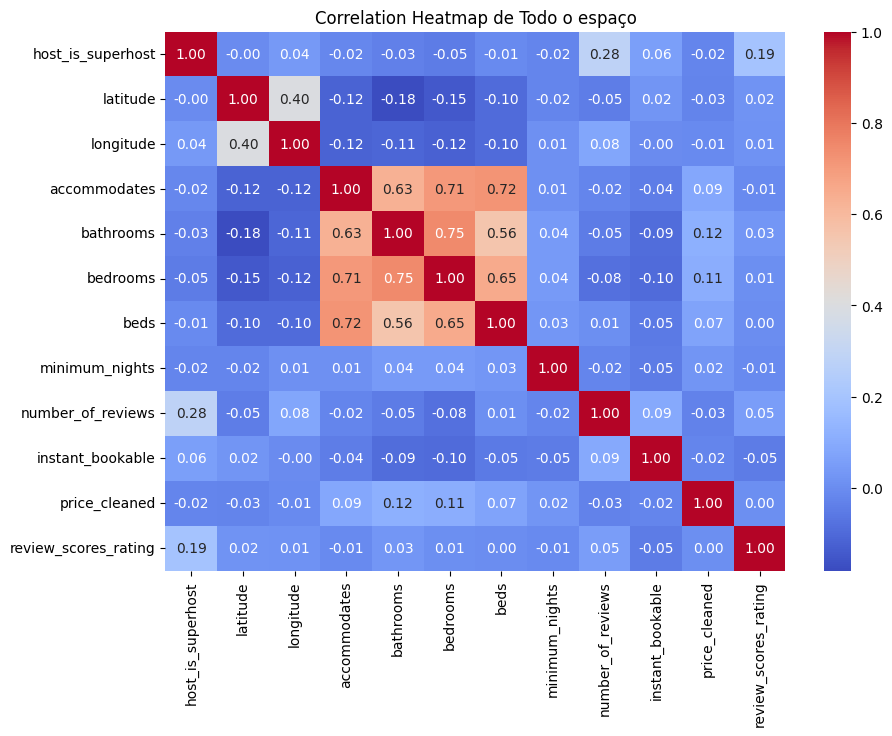

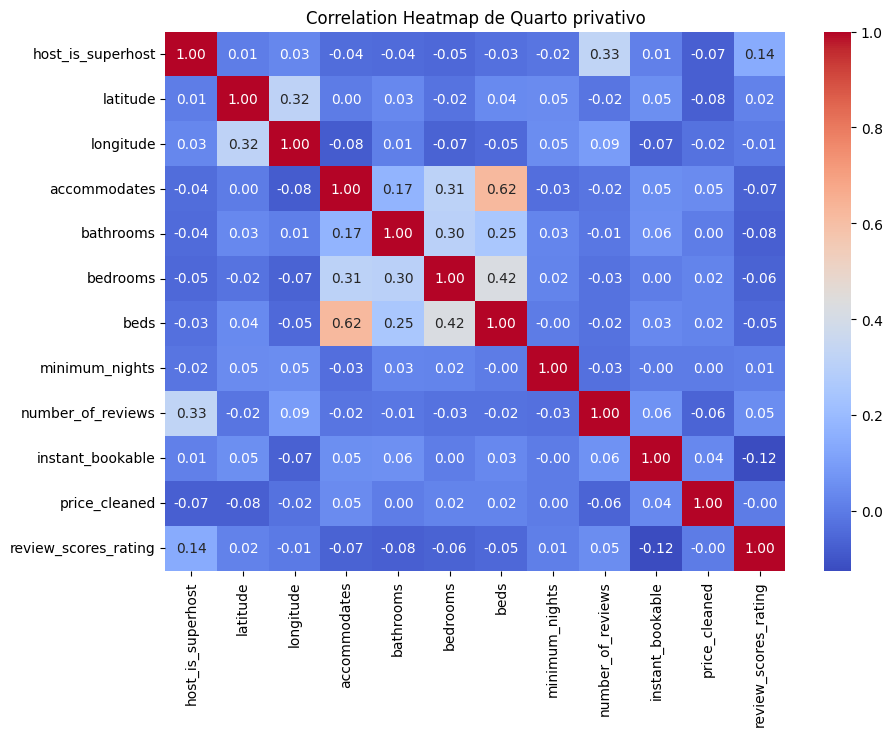

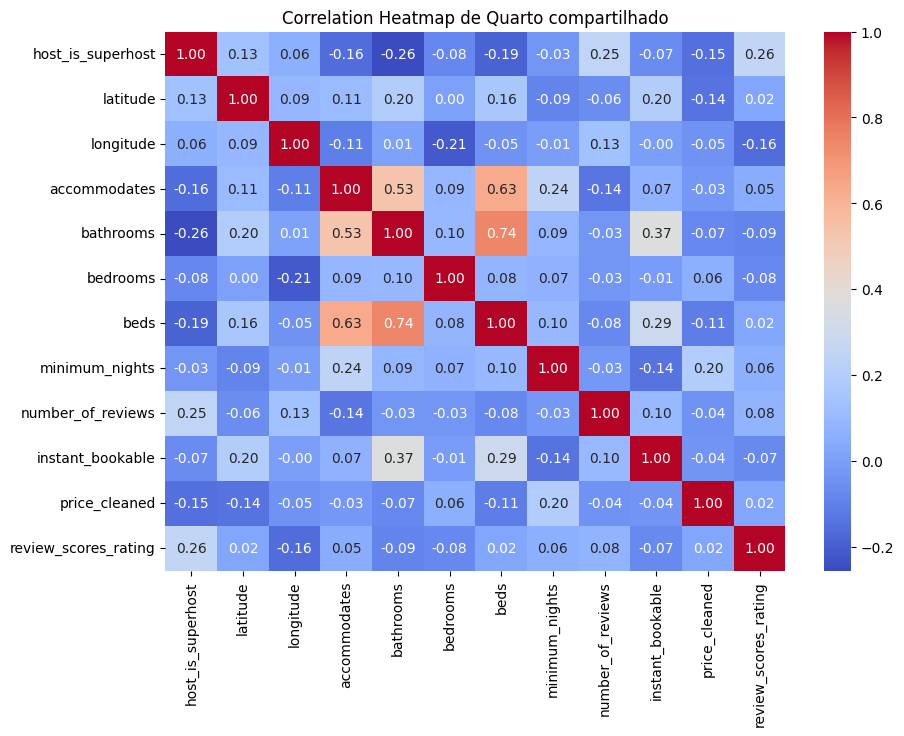

In [110]:
for room in room_trad.values():
    plt.figure(figsize=(10, 7))
    corr = dfs_por_quartos[room][[
        'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
        'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
        'instant_bookable', 'price_cleaned', 'review_scores_rating'
        # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
        ]].dropna().corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Heatmap de {room}' )
    plt.show()

In [94]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [73]:
df_rating_pred = df_treatment.copy()
df_rating_pred = df_rating_pred.dropna(subset=['room_type'])

In [74]:
df_treatment.room_type.value_counts()

room_type
Todo o espaço           34495
Quarto privativo         8124
Quarto compartilhado      427
Name: count, dtype: int64

## Previsão de Rating

In [75]:
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
import numpy as np
RANDOM_SEED = 42

df_rating_pred = df_rating_pred.dropna()
df_copa = df_rating_pred[df_rating_pred['neighbourhood_cleansed'] == 'Copacabana']
X = df_rating_pred.drop(columns=['review_scores_rating'])
y = df_rating_pred['review_scores_rating'].values
# X = df_copa.drop(columns=['review_scores_rating'])
# y = df_copa['review_scores_rating'].values

In [76]:
X.room_type.value_counts()

room_type
Todo o espaço           10108
Quarto privativo         1733
Quarto compartilhado       79
Name: count, dtype: int64

In [77]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_rating_pred[['room_type']])
# enc.categories_
one_hot = enc.transform(df_rating_pred[['room_type']]).toarray()
# one_hot = enc.transform(df_copa[['room_type']]).toarray()
X[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned']

Text(0.5, 1.0, 'Correlation Heatmap')

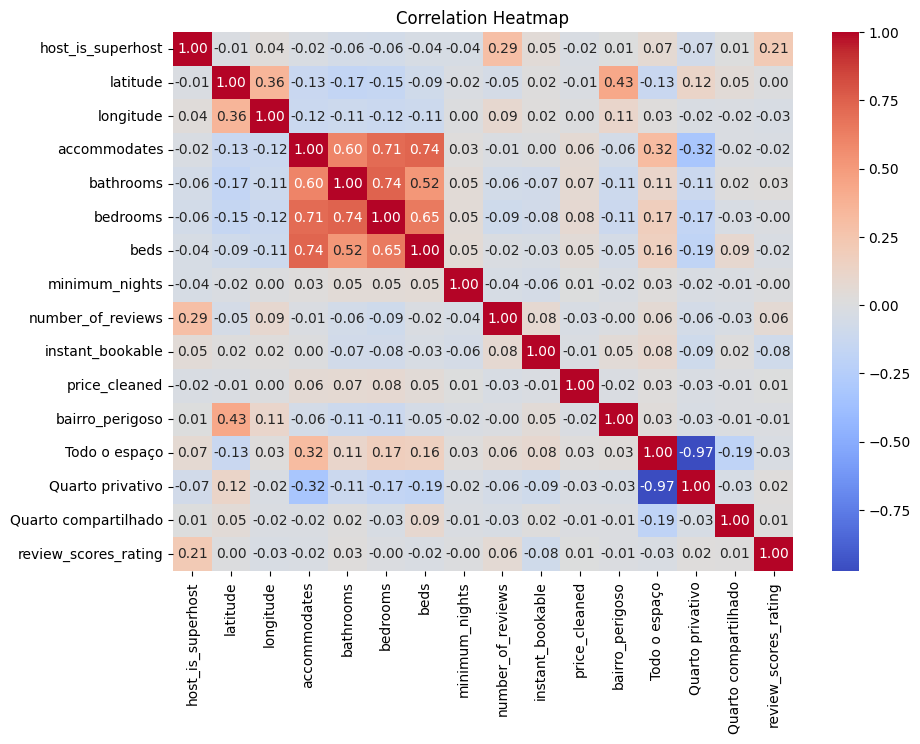

In [78]:
plt.figure(figsize=(10, 7))
X_com_y = X[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].copy()

X_com_y['review_scores_rating'] = y

corr = X_com_y.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')